# Avaliação — APIs de energia renovável e aprendizado de máquina

**Objetivo:** consultar duas APIs públicas (ANEEL/SIGA e Open-Meteo), gerar dois CSVs e resolver duas tarefas independentes, comparando **três algoritmos em cada uma**:

- **Tarefa 1 (classificação):** prever a fonte de um empreendimento (Solar, Eólica ou Hidráulica) a partir de potência e localização.
- **Tarefa 2 (regressão):** estimar a radiação solar horária em Petrolina (PE) a partir de variáveis meteorológicas e da hora.

**Como executar:** rode as células na ordem (*Kernel → Restart & Run All*). As APIs são públicas e não exigem token. Nenhuma credencial é usada neste notebook.

**Índice**
1. Consulta às APIs e geração dos CSVs (notebook de apoio)
2. Imports e configuração
3. Tarefa 1 — Classificação (ANEEL)
4. Tarefa 2 — Regressão (Open-Meteo)
5. Conclusões gerais

## 1. Consulta às APIs e geração dos CSVs (notebook de apoio)

In [1]:
import json
import urllib.parse
import urllib.request
import csv

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

### 1.1 ANEEL (SIGA)

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [4]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas
Total de linhas recebidas: 3876


In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [6]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### 1.2 Open-Meteo (histórico)

In [7]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [8]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


In [9]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [10]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


## 2. Imports e configuração

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingRegressor)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             mean_absolute_error, mean_squared_error, r2_score)

SEED = 42          # semente fixa em todo o notebook
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 100

## 3. Tarefa 1 — Classificação da fonte (ANEEL/SIGA)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como Solar, Eólica ou Hidráulica?

Cada linha do CSV é um empreendimento (em fases variadas do cadastro). A potência é a **outorgada** (kW), não a energia gerada.

### 3.1 Carga e exploração dos dados

In [12]:
df = pd.read_csv("aneel_classificacao_orange.csv")
print("Linhas x colunas:", df.shape)
print("\nTipos das colunas:")
print(df.dtypes)
print("\nValores ausentes por coluna:")
print(df.isna().sum())
print("\nPrimeiras linhas:")
df.head()

Linhas x colunas: (3876, 4)

Tipos das colunas:
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Valores ausentes por coluna:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Primeiras linhas:


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.443,-64.152,Solar
1,5000.00,-6.004,-40.275,Solar
2,12.26,-23.558,-46.734,Solar
3,3.00,-23.559,-46.735,Solar
4,1.70,-23.494,-46.845,Solar


            quantidade  proporção
fonte                            
Hidráulica        1476      0.381
Solar             1200      0.310
Eólica            1200      0.310


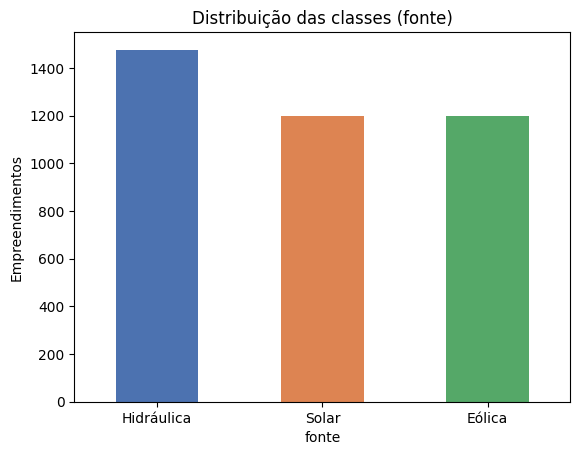

In [13]:
contagem = df["fonte"].value_counts()
proporcao = df["fonte"].value_counts(normalize=True).round(3)
print(pd.DataFrame({"quantidade": contagem, "proporção": proporcao}))

contagem.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Distribuição das classes (fonte)")
plt.ylabel("Empreendimentos"); plt.xticks(rotation=0); plt.show()

In [14]:
print(df.groupby("fonte")[["potencia_kw", "latitude", "longitude"]].describe().T)

fonte                  Eólica  Hidráulica       Solar
potencia_kw count    1200.000   1.476e+03    1200.000
            mean    30782.770   7.581e+04   11679.387
            std     13800.598   4.864e+05   18374.855
            min         0.160   9.900e-01       0.260
            25%     23100.000   9.900e+02       1.000
            50%     29600.000   4.000e+03       1.000
            75%     37200.000   1.700e+04   28880.000
            max    105000.000   1.123e+07  137480.000
latitude    count    1200.000   1.476e+03    1200.000
            mean       -9.896  -2.111e+01      -5.136
            std         7.530   6.500e+00       5.547
            min       -33.723  -3.079e+01     -29.836
            25%       -11.136  -2.675e+01      -6.925
            50%        -7.986  -2.203e+01      -2.056
            75%        -5.271  -1.760e+01      -1.831
            max         0.000   3.802e+00       3.831
longitude   count    1200.000   1.476e+03    1200.000
            mean      -39.71

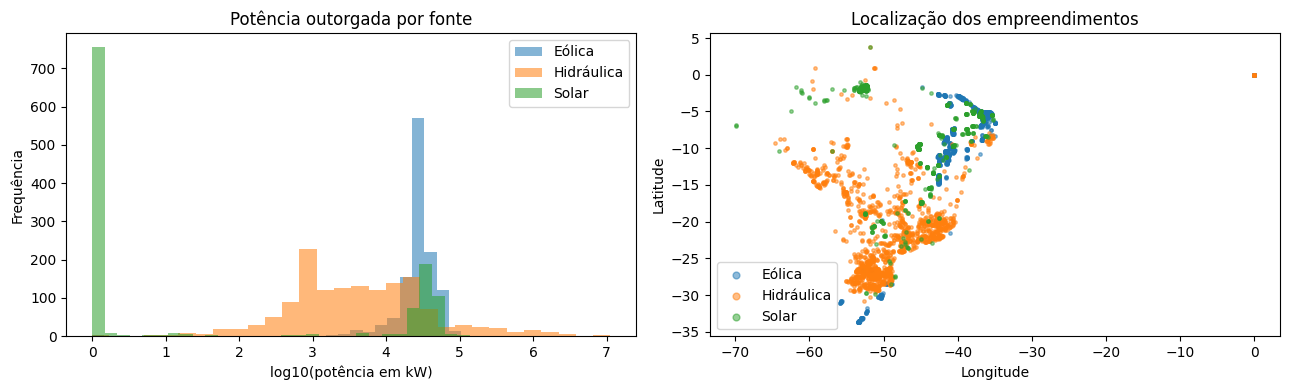

In [15]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4))

# Potência em escala logarítmica (distribuição muito assimétrica)
for fonte, g in df.groupby("fonte"):
    eixos[0].hist(np.log10(g["potencia_kw"].clip(lower=1)), bins=30, alpha=.55, label=fonte)
eixos[0].set_xlabel("log10(potência em kW)"); eixos[0].set_ylabel("Frequência")
eixos[0].set_title("Potência outorgada por fonte"); eixos[0].legend()

# Localização
for fonte, g in df.groupby("fonte"):
    eixos[1].scatter(g["longitude"], g["latitude"], s=6, alpha=.5, label=fonte)
eixos[1].set_xlabel("Longitude"); eixos[1].set_ylabel("Latitude")
eixos[1].set_title("Localização dos empreendimentos"); eixos[1].legend(markerscale=2)
plt.tight_layout(); plt.show()

**Observações da exploração** (confira com as saídas acima):

- O CSV já vem sem linhas sem potência/coordenadas (o notebook de apoio as descarta), então normalmente não há ausentes. Se a contagem acima mostrar algum, a decisão é remover as linhas, pois são poucas e imputar coordenadas inventaria localização.
- As classes **não têm o mesmo tamanho**: a consulta limita cada sigla a 1200 linhas e a classe Hidráulica reúne três siglas (UHE, PCH, CGH). Portanto a proporção observada **não representa a matriz elétrica real** do Brasil.
- A potência é muito assimétrica (muitas usinas pequenas e poucas gigantes), por isso o histograma usa escala logarítmica. Modelos baseados em distância (KNN) e a regressão logística são sensíveis a essa escala, o que justifica a padronização.
- As classes ocupam regiões geográficas diferentes (eólicas concentradas no Nordeste e Sul, hidráulicas nas bacias do Sudeste/Sul/Centro-Oeste, solares mais espalhadas), o que dá sinal útil à latitude e longitude.

### 3.2 Definição de X e y e divisão treino/teste

- **X:** `potencia_kw`, `latitude`, `longitude` (três entradas numéricas).
- **y:** `fonte` (Solar, Eólica, Hidráulica).
- **Não usados como entrada:** `SigTipoGeracao`, nome, código CEG e descrições do combustível, pois revelam a classe.
- **Divisão:** 80% treino / 20% teste, **estratificada** (mantém a proporção das classes) e com **semente fixa** (`random_state=42`). Os três modelos usam exatamente a mesma divisão.

In [16]:
X = df[["potencia_kw", "latitude", "longitude"]]
y = df["fonte"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("\nProporção das classes no treino:\n", y_train.value_counts(normalize=True).round(3))
print("\nProporção das classes no teste:\n", y_test.value_counts(normalize=True).round(3))

Treino: (3100, 3) | Teste: (776, 3)

Proporção das classes no treino:
 fonte
Hidráulica    0.381
Solar         0.310
Eólica        0.310
Name: proportion, dtype: float64

Proporção das classes no teste:
 fonte
Hidráulica    0.381
Solar         0.309
Eólica        0.309
Name: proportion, dtype: float64


### 3.3 Modelos escolhidos

| Modelo | Por que | Padronização |
|---|---|---|
| **Regressão Logística** | Linha de base linear e interpretável | Sim (dentro do `Pipeline`, ajustada só no treino) |
| **KNN (k=5)** | Classifica por vizinhança: faz sentido com coordenadas geográficas | Sim (dentro do `Pipeline`) |
| **Random Forest** | Captura relações não lineares e interações potência × localização; robusto a escalas | Não precisa |

Ao usar `Pipeline`, o `StandardScaler` é ajustado **somente com os dados de treino** a cada `fit`, o que evita vazamento de informação do teste.

In [17]:
modelos_clf = {
    "Regressão Logística": Pipeline([("scaler", StandardScaler()),
                                     ("modelo", LogisticRegression(max_iter=2000, random_state=SEED))]),
    "KNN (k=5)":           Pipeline([("scaler", StandardScaler()),
                                     ("modelo", KNeighborsClassifier(n_neighbors=5))]),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=SEED),
}

classes = sorted(y.unique())
resultados_clf, previsoes_clf = [], {}

for nome, modelo in modelos_clf.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    previsoes_clf[nome] = pred
    resultados_clf.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (macro)": precision_score(y_test, pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, pred, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_test, pred, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_test, pred, average="weighted", zero_division=0),
    })

tabela_clf = pd.DataFrame(resultados_clf).set_index("Modelo")
print("Configuração de avaliação: mesmo conjunto de teste (20%, estratificado, seed=42) para os 3 modelos.")
print("Média das métricas por classe: MACRO (todas as classes pesam igual). F1 weighted incluído como referência.\n")
tabela_clf.round(3)

Configuração de avaliação: mesmo conjunto de teste (20%, estratificado, seed=42) para os 3 modelos.
Média das métricas por classe: MACRO (todas as classes pesam igual). F1 weighted incluído como referência.



,Accuracy,Precision (macro),Recall (macro),F1 (macro),F1 (weighted)
Modelo,,,,,
Regressão Logística,0.825,0.828,0.821,0.820,0.823
KNN (k=5),0.965,0.966,0.964,0.965,0.965
Random Forest,0.976,0.977,0.974,0.975,0.975


### 3.4 Métricas e matrizes de confusão

**Tipo de média:** usei **macro** para Precision, Recall e F1. A média macro calcula a métrica de cada classe e tira a média simples, tratando todas as classes com o mesmo peso. Isso é adequado porque as classes têm tamanhos diferentes e não queremos que a classe maior mascare o mau desempenho nas menores. O F1 *weighted* (ponderado pelo tamanho de cada classe) aparece na última coluna apenas para comparação.

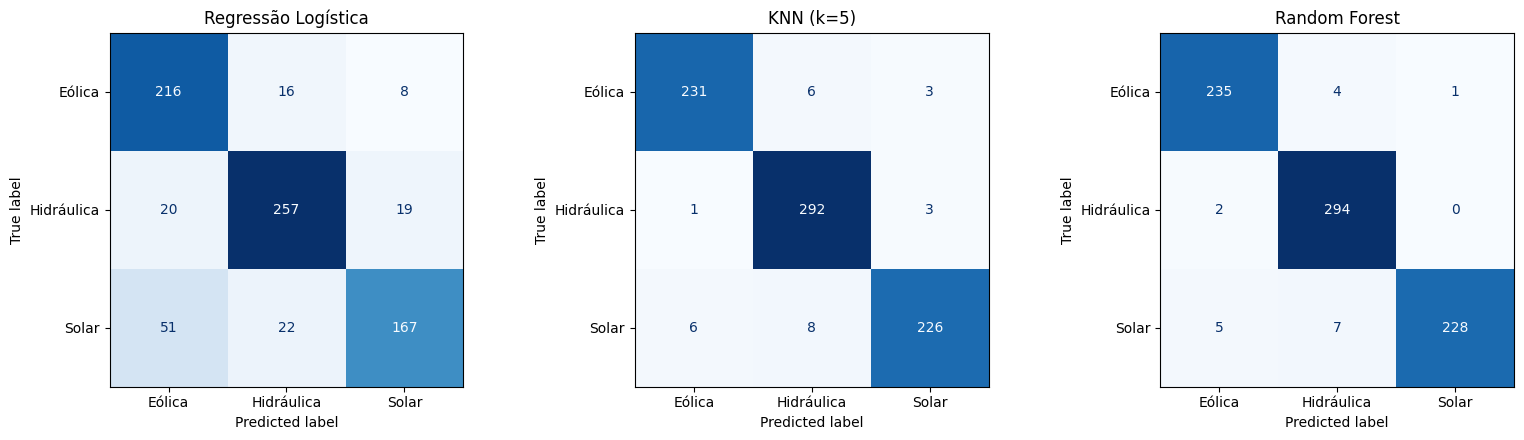

In [18]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (nome, pred) in zip(eixos, previsoes_clf.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=classes, ax=ax,
                                            colorbar=False, cmap="Blues")
    ax.set_title(nome)
plt.tight_layout(); plt.show()

In [19]:
# Métricas por classe do melhor modelo (pelo F1 macro)
melhor_clf = tabela_clf["F1 (macro)"].idxmax()
print("Melhor classificador pelo F1 macro:", melhor_clf, "\n")
from sklearn.metrics import classification_report
print(classification_report(y_test, previsoes_clf[melhor_clf], zero_division=0))

# Par de classes mais confundido no melhor modelo
cm = confusion_matrix(y_test, previsoes_clf[melhor_clf], labels=classes)
erros = [(classes[i], classes[j], cm[i, j]) for i in range(len(classes))
         for j in range(len(classes)) if i != j]
erros.sort(key=lambda t: -t[2])
print("Erros mais frequentes (classe real -> prevista):")
for real, prev, n in erros[:3]:
    print(f"  {real} -> {prev}: {n} casos")

Melhor classificador pelo F1 macro: Random Forest 

              precision    recall  f1-score   support

      Eólica       0.97      0.98      0.98       240
  Hidráulica       0.96      0.99      0.98       296
       Solar       1.00      0.95      0.97       240

    accuracy                           0.98       776
   macro avg       0.98      0.97      0.98       776
weighted avg       0.98      0.98      0.98       776

Erros mais frequentes (classe real -> prevista):
  Solar -> Hidráulica: 7 casos
  Solar -> Eólica: 5 casos
  Eólica -> Hidráulica: 4 casos


### 3.5 Interpretação — Tarefa 1

**Modelo escolhido.** O melhor modelo é indicado pela tabela do item 3.3 (maior F1 macro, impresso acima). Em problemas com fronteiras irregulares no espaço geográfico, como este, é esperado que o **Random Forest** e o **KNN** superem a regressão logística, que só traça fronteiras lineares. Confirme com os números da sua execução e cite os valores na conclusão do README.

**Classes mais confundidas.** A célula anterior mostra os pares de classes com mais erros. Os motivos típicos:

- **Solar × Hidráulica (pequenas):** usinas fotovoltaicas e centrais hidrelétricas pequenas (CGH/PCH) têm potências na mesma faixa (poucos MW ou menos) e podem estar nas mesmas regiões.
- **Solar × Eólica:** ambas se concentram no Nordeste, onde há sol e vento fortes, então latitude/longitude ajudam pouco a separá-las.
- Hidráulica tende a ser mais fácil quando a potência é muito alta (UHE), mas isso cobre poucos exemplos.

**Limitações de prever a fonte só por potência e localização:**

1. Potência outorgada é o valor autorizado, **não** a energia gerada.
2. Coordenadas são aproximadas.
3. O cadastro mistura empreendimentos em diferentes fases (planejados, em construção, operando), o que adiciona ruído.
4. Faltam variáveis decisivas: recurso disponível (rios, vento, irradiação), tipo de terreno, proximidade de linhas de transmissão.
5. As classes estão desbalanceadas por construção da consulta (limite de 1200 por sigla e Hidráulica agrupando três siglas), então as proporções não refletem a realidade.
6. Uma única divisão treino/teste dá uma estimativa com alguma variabilidade; validação cruzada daria mais estabilidade.

Portanto o modelo serve como exercício de aprendizado, mas **não** como ferramenta para decidir a fonte de um empreendimento real.

## 4. Tarefa 2 — Regressão da radiação solar (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora?

Dados históricos horários (modelo/reanálise, **não** um sensor ou painel) de 01/04/2025 a 30/06/2025, fuso America/Recife, apenas horas de 7h a 17h.

### 4.1 Carga e exploração

In [20]:
dfm = pd.read_csv("meteo_regressao_orange.csv")
dfm["data_hora"] = pd.to_datetime(dfm["data_hora"])
dfm = dfm.sort_values("data_hora").reset_index(drop=True)

print("Linhas x colunas:", dfm.shape)
print("Período:", dfm["data_hora"].min(), "->", dfm["data_hora"].max())
print("\nTipos das colunas:"); print(dfm.dtypes)
print("\nValores ausentes por coluna:"); print(dfm.isna().sum())
dfm.describe().T

Linhas x colunas: (1001, 7)
Período: 2025-04-01 07:00:00 -> 2025-06-30 17:00:00

Tipos das colunas:
data_hora        datetime64[ns]
temperatura_c           float64
umidade_pct               int64
nuvens_pct                int64
vento_kmh               float64
hora                      int64
radiacao_w_m2           float64
dtype: object

Valores ausentes por coluna:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,count,mean,min,25%,50%,75%,max,std
data_hora,1001,2025-05-16 11:59:59.999999744,2025-04-01 07:00:00,2025-04-23 15:00:00,2025-05-16 12:00:00,2025-06-08 09:00:00,2025-06-30 17:00:00,NaN
temperatura_c,1001.0,28.886,19.5,26.3,29.1,31.7,36.1,3.657
umidade_pct,1001.0,50.544,21.0,38.0,49.0,61.0,95.0,15.914
nuvens_pct,1001.0,55.109,0.0,19.0,54.0,98.0,100.0,37.851
vento_kmh,1001.0,15.465,2.3,12.2,15.4,19.0,30.1,4.924
hora,1001.0,12.0,7.0,9.0,12.0,15.0,17.0,3.164
radiacao_w_m2,1001.0,472.854,13.0,250.0,466.0,696.0,1002.0,256.369


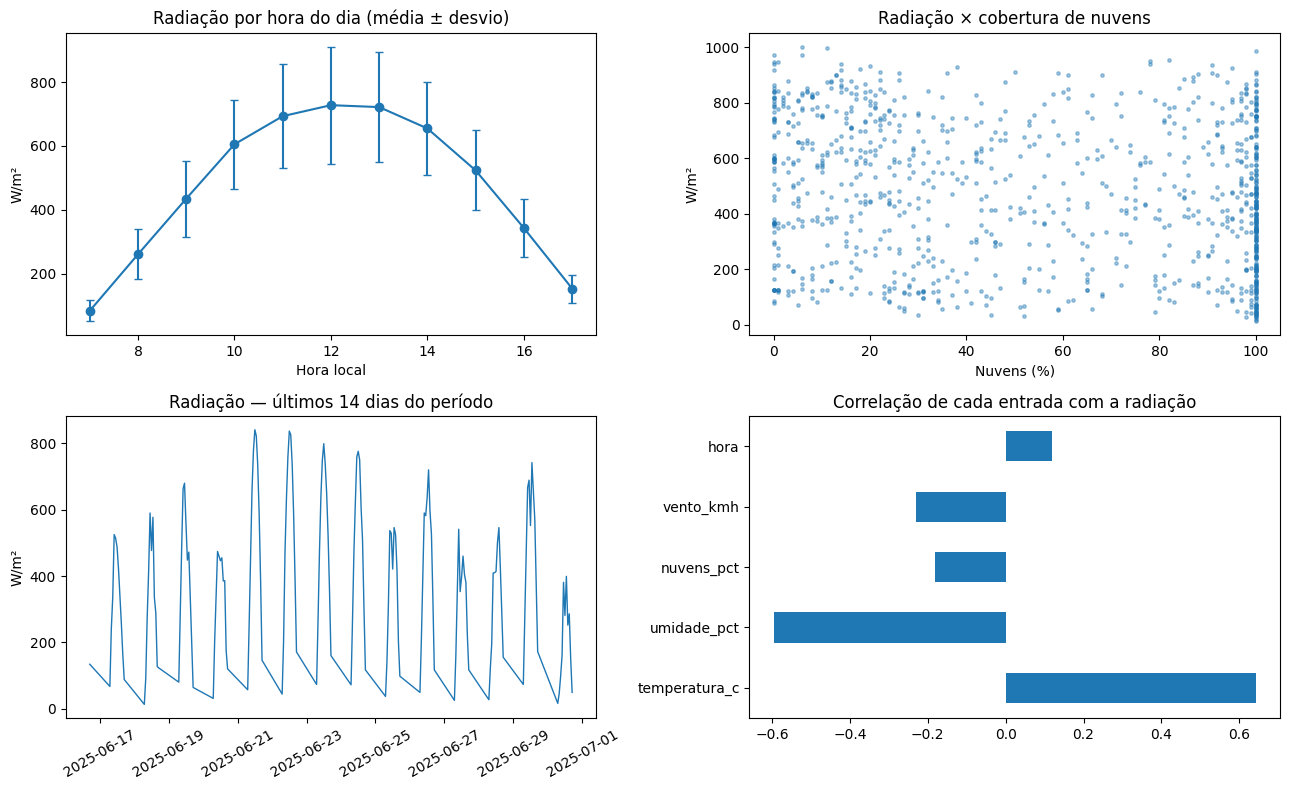

In [21]:
fig, eixos = plt.subplots(2, 2, figsize=(13, 8))

# 1) Radiação média por hora do dia
media_hora = dfm.groupby("hora")["radiacao_w_m2"].agg(["mean", "std"])
eixos[0, 0].errorbar(media_hora.index, media_hora["mean"], yerr=media_hora["std"],
                     marker="o", capsize=3)
eixos[0, 0].set_title("Radiação por hora do dia (média ± desvio)")
eixos[0, 0].set_xlabel("Hora local"); eixos[0, 0].set_ylabel("W/m²")

# 2) Radiação x nuvens
eixos[0, 1].scatter(dfm["nuvens_pct"], dfm["radiacao_w_m2"], s=6, alpha=.4)
eixos[0, 1].set_title("Radiação × cobertura de nuvens")
eixos[0, 1].set_xlabel("Nuvens (%)"); eixos[0, 1].set_ylabel("W/m²")

# 3) Série temporal (último mês para legibilidade)
recorte = dfm[dfm["data_hora"] >= dfm["data_hora"].max() - pd.Timedelta(days=14)]
eixos[1, 0].plot(recorte["data_hora"], recorte["radiacao_w_m2"], lw=1)
eixos[1, 0].set_title("Radiação — últimos 14 dias do período")
eixos[1, 0].tick_params(axis="x", rotation=30); eixos[1, 0].set_ylabel("W/m²")

# 4) Correlações com o alvo
corr = dfm[["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora",
            "radiacao_w_m2"]].corr()["radiacao_w_m2"].drop("radiacao_w_m2")
corr.plot(kind="barh", ax=eixos[1, 1])
eixos[1, 1].set_title("Correlação de cada entrada com a radiação")
plt.tight_layout(); plt.show()

**Observações da exploração:**

- O CSV já exclui linhas com valores ausentes (o notebook de apoio as descarta), então normalmente não há ausentes. Caso a contagem acima mostre algum, a decisão seria remover a linha, pois preencher um valor meteorológico horário de forma arbitrária distorceria a relação com o alvo.
- A radiação tem forte padrão diário: baixa no início da manhã, máxima perto do meio-dia e queda à tarde. A cobertura de nuvens reduz a radiação, mas a relação não é uma reta, pois depende também da hora.
- Como a correlação linear da `hora` com a radiação é fraca (a curva é em formato de sino, não uma reta), isso já antecipa que modelos lineares terão dificuldade.

### 4.2 Definição de X e y e divisão temporal

- **X (5 entradas):** `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora`.
- **y:** `radiacao_w_m2`.
- `data_hora` só serve para ordenar e dividir; **não** é entrada. `radiacao_w_m2` (ou qualquer transformação dela) **não** entra em X.
- **Divisão:** as **primeiras 80%** das horas para treino e as **últimas 20%** para teste, **sem embaralhar**, respeitando a ordem temporal. Os três modelos usam a mesma divisão.

In [22]:
features = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X = dfm[features]
y = dfm["radiacao_w_m2"]
assert "radiacao_w_m2" not in X.columns

corte = int(len(dfm) * 0.8)
X_tr, X_te = X.iloc[:corte], X.iloc[corte:]
y_tr, y_te = y.iloc[:corte], y.iloc[corte:]

print(f"Treino: {len(X_tr)} horas ({dfm['data_hora'].iloc[0].date()} -> {dfm['data_hora'].iloc[corte-1].date()})")
print(f"Teste:  {len(X_te)} horas ({dfm['data_hora'].iloc[corte].date()} -> {dfm['data_hora'].iloc[-1].date()})")

Treino: 800 horas (2025-04-01 -> 2025-06-12)
Teste:  201 horas (2025-06-12 -> 2025-06-30)


### 4.3 Modelos escolhidos

| Modelo | Por que | Padronização |
|---|---|---|
| **Regressão Linear** | Linha de base simples; mostra o limite de uma relação linear | Sim (no `Pipeline`, ajustada só no treino) |
| **Random Forest Regressor** | Aprende relações não lineares (o formato de sino da hora) e interações hora × nuvens | Não precisa |
| **Gradient Boosting Regressor** | Boosting: árvores em sequência corrigindo erros; costuma ser muito competitivo em dados tabulares | Não precisa |

In [23]:
modelos_reg = {
    "Regressão Linear":  Pipeline([("scaler", StandardScaler()), ("modelo", LinearRegression())]),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=SEED),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED),
}

resultados_reg, previsoes_reg = [], {}
for nome, modelo in modelos_reg.items():
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)
    previsoes_reg[nome] = pred
    resultados_reg.append({
        "Modelo": nome,
        "MAE (W/m²)": mean_absolute_error(y_te, pred),
        "MSE ((W/m²)²)": mean_squared_error(y_te, pred),
        "R²": r2_score(y_te, pred),
    })

tabela_reg = pd.DataFrame(resultados_reg).set_index("Modelo")
print("Configuração de avaliação: mesmas 80% primeiras horas p/ treino e 20% finais p/ teste, sem embaralhar, para os 3 modelos.\n")
tabela_reg.round(3)

Configuração de avaliação: mesmas 80% primeiras horas p/ treino e 20% finais p/ teste, sem embaralhar, para os 3 modelos.



,MAE (W/m²),MSE ((W/m²)²),R²
Modelo,,,
Regressão Linear,145.205,30034.201,0.360
Random Forest,66.252,7250.888,0.845
Gradient Boosting,67.082,7444.700,0.841


### 4.4 Gráfico de valores reais × previstos

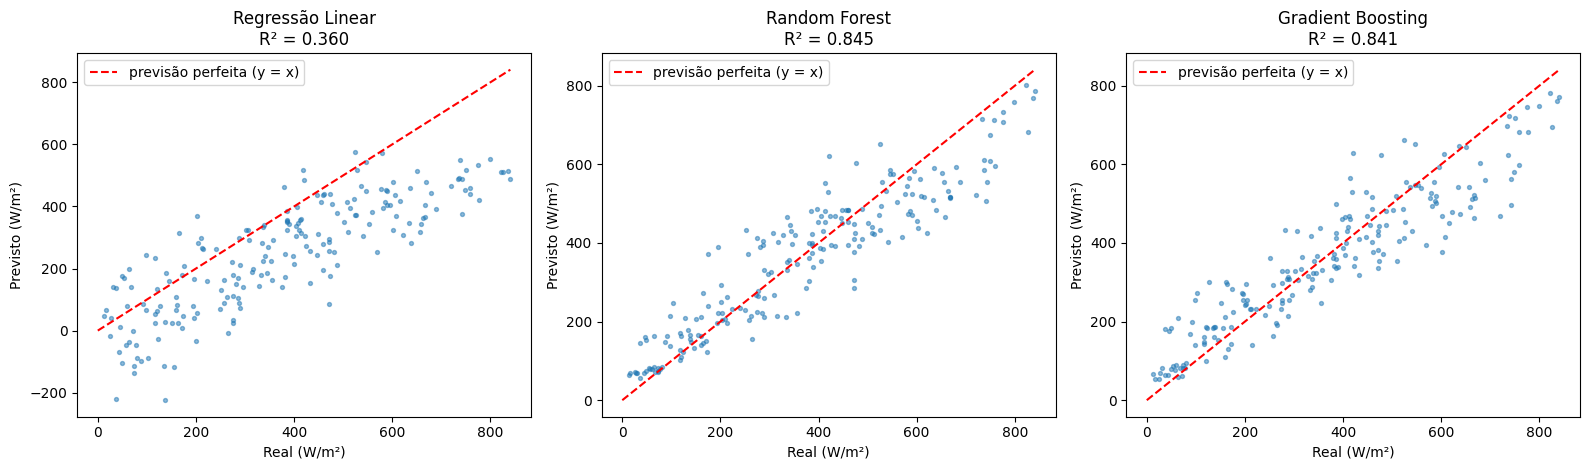

In [24]:
fig, eixos = plt.subplots(1, 3, figsize=(16, 4.8))
lim = [0, max(y_te.max(), *(p.max() for p in previsoes_reg.values()))]
for ax, (nome, pred) in zip(eixos, previsoes_reg.items()):
    ax.scatter(y_te, pred, s=8, alpha=.5)
    ax.plot(lim, lim, "r--", label="previsão perfeita (y = x)")
    ax.set_title(f"{nome}\nR² = {r2_score(y_te, pred):.3f}")
    ax.set_xlabel("Real (W/m²)"); ax.set_ylabel("Previsto (W/m²)"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

Melhor regressor pelo MAE: Random Forest


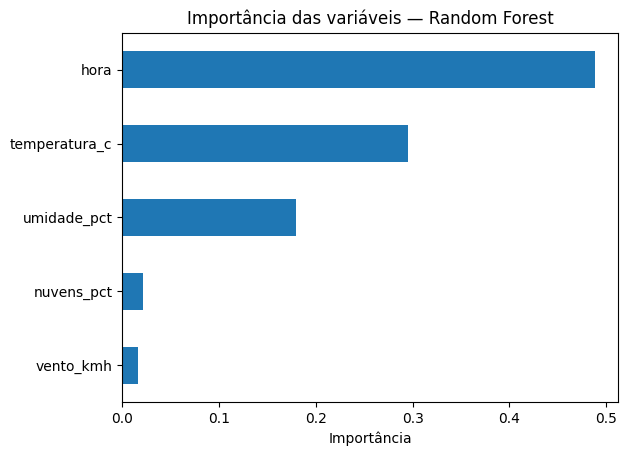

hora             0.488
temperatura_c    0.295
umidade_pct      0.179
nuvens_pct       0.022
vento_kmh        0.016
dtype: float64


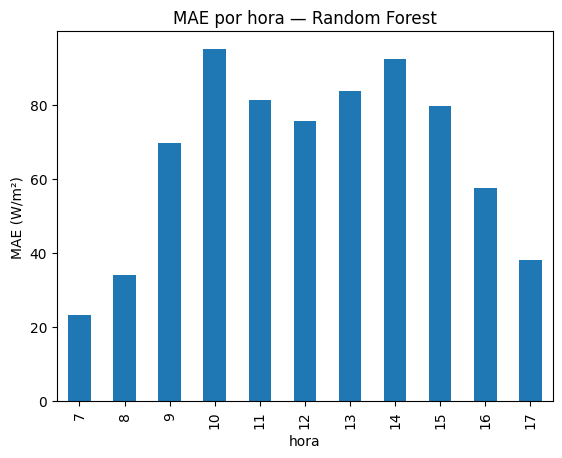

In [25]:
melhor_reg = tabela_reg["MAE (W/m²)"].idxmin()
print("Melhor regressor pelo MAE:", melhor_reg)

# Peso de cada variável no Random Forest
rf = modelos_reg["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
imp.plot(kind="barh", title="Importância das variáveis — Random Forest")
plt.xlabel("Importância"); plt.show()
print(imp.sort_values(ascending=False).round(3))

# Erro do melhor modelo por hora do dia
res = pd.DataFrame({"hora": X_te["hora"].values,
                    "erro_abs": np.abs(y_te.values - previsoes_reg[melhor_reg])})
res.groupby("hora")["erro_abs"].mean().plot(kind="bar", title=f"MAE por hora — {melhor_reg}")
plt.ylabel("MAE (W/m²)"); plt.show()

### 4.5 Interpretação — Tarefa 2

**Comparação dos modelos.** A tabela do item 4.3 traz MAE, MSE e R² no mesmo conjunto de teste. O MAE está na mesma unidade do alvo (W/m²) e diz o erro médio típico; o MSE penaliza mais os erros grandes (está em (W/m²)²); o R² indica a fração da variância explicada. Compare o MAE com a escala da radiação (picos em torno de 900 a 1000 W/m² ao meio-dia) para julgar se o erro é pequeno ou grande. Espera-se que os modelos de árvores (Random Forest e Gradient Boosting) superem a Regressão Linear, porque a relação entre hora e radiação tem forma de sino e a linear só ajusta uma reta.

**Papel da hora do dia.** A radiação solar segue o ciclo diário determinado pela posição do Sol: cresce da manhã até o meio-dia e decresce à tarde. A variável `hora` carrega esse padrão e, no gráfico de importâncias, tende a ser uma das mais relevantes. As nuvens modulam a intensidade em cada hora (com céu encoberto a radiação cai), mas quem define o "teto" possível é a hora. Sem `hora`, o modelo confundiria manhã cedo com meio-dia nublado. O gráfico do erro por hora mostra onde o modelo erra mais: normalmente perto do meio-dia, quando os valores são maiores e uma pequena diferença de nuvem pesa mais em W/m².

**Radiação estimada não é geração elétrica.** O alvo é a radiação global horizontal, uma grandeza meteorológica. A energia que um sistema fotovoltaico gera depende ainda de: eficiência e área dos módulos, temperatura das células (calor reduz a eficiência), inclinação e orientação dos painéis (a radiação aqui é sobre superfície horizontal), perdas no inversor e na fiação, sujeira, sombreamento e limitações da rede. Além disso, W/m² é potência instantânea média da hora, e não energia em kWh, e os dados vêm de modelo/reanálise, não de um sensor no local.

**Limitações da avaliação.** O período de teste são as últimas semanas (fim de junho, início do inverno no hemisfério sul), com condições possivelmente diferentes do treino (abril-maio), o que pode reduzir o desempenho. Apenas um trimestre de dados foi usado, e nenhum ajuste de hiperparâmetros foi feito (foram usados valores padrão razoáveis).

## 5. Conclusões gerais

Preencha esta seção (e o README) com os números da sua execução:

- **Tarefa 1:** melhor modelo, seu F1 macro e sua accuracy; par de classes mais confundido; principal limitação.
- **Tarefa 2:** melhor modelo, seu MAE, MSE e R²; papel da hora; por que radiação não é geração.

As duas tabelas de resultados (itens 3.3 e 4.3) identificam os três algoritmos de cada tarefa e a configuração de avaliação usada (mesma divisão para os três modelos em cada tarefa).